# EIGSEP Signal Recovery (v001)

- Composed objects: `Observer`, `Beam`, `Sky`, `Terrain`, `ForwardModel`
- Spectral basis decomposition: `BeamBasis`, `SkyBasis`
- Joint optimization: `Calibrator` with Anderson Acceleration + JAX autodiff

In [1]:
import os
import numpy as np
import healpy
import matplotlib.pyplot as plt
from astropy.time import Time
import astropy.units as u

from eigsep_sim import (
    EarthSurface, Beam, Sky, NullTerrain, ForwardModel, Calibrator,
    DTYPE_R_NPY, DTYPE_R_JAX
)
from eigsep_sim.recovery import RecoverySolution, ScaleDegeneracy
from eigsep_sim.models import T21cmModel
from eigsep_sim.recovery import normal_solve
from eigsep_sim.spectral import gsm_eigenmodes, eigenmode_filter

# Configuration
NSIDE = 8
N_FREQ = 20
NPIX = healpy.nside2npix(NSIDE)
LAT_DEG, LON_DEG = 39.2, -113.4
FREQS_MHZ = np.linspace(55.0, 150.0, N_FREQ)
FREQS_HZ = FREQS_MHZ * 1e6
DELTA_NU_HZ = float(np.diff(FREQS_MHZ).mean()) * 1e6
OBS_EPOCH = Time("2025-01-01")
N_TIMES = 36
N_AZ, N_ALT = 12, 10
N_ORIENT = N_AZ * N_ALT
N_BEAM_POLS = 1
if N_BEAM_POLS not in (1, 2):
    raise ValueError("N_BEAM_POLS must be 1 or 2")
BEAM_AXES_BODY = np.eye(3, dtype=DTYPE_R_NPY)[:N_BEAM_POLS]
AZ_RAD = np.linspace(0.0, 2.0 * np.pi, N_AZ, endpoint=False)
ALT_RAD = np.linspace(0.0, 0.5 * np.pi, N_ALT)
ORIENT_ROTS = np.stack([
    Beam.top2body(az, alt) for alt in ALT_RAD for az in AZ_RAD
])
T_RX_K = 100.0

print(f"Config: NSIDE={NSIDE}, N_FREQ={N_FREQ}, N_TIMES={N_TIMES}, "
      f"N_ORIENT={N_ORIENT}, N_BEAM_POLS={N_BEAM_POLS}")

Config: NSIDE=8, N_FREQ=20, N_TIMES=36, N_ORIENT=120, N_BEAM_POLS=1


In [2]:
# Create Observer, Beam, Sky
obs = EarthSurface(lat=LAT_DEG, lon=LON_DEG)
beam = Beam.from_dipole(nside=8, freqs_hz=FREQS_HZ, arm_lengths_m=2.0, u_body=BEAM_AXES_BODY, K=5)
sky = Sky.from_gsm(NSIDE, FREQS_HZ, n_modes=5, include_flat=True)
gsm_maps = sky.init_coeffs()
gsm_maps_recon = gsm_maps @ sky.basis.A.T
fwd = ForwardModel(obs, beam, sky, terrain=NullTerrain())

In [3]:
# Precompute geometry for every sidereal time and beam orientation
base_times = OBS_EPOCH + np.linspace(0, 86400, N_TIMES, endpoint=False) * u.s
base_rots = obs.rot_gal2top_stack(base_times)
rots = np.repeat(base_rots, N_ORIENT, axis=0)
body_rots = np.tile(ORIENT_ROTS, (N_TIMES, 1, 1))
geom = fwd.precompute_geometry(rots=rots, body_rots=body_rots)

# Forward simulation
sky_coeffs = gsm_maps
beam_coeffs = beam.coeffs.copy()
antenna_temp = fwd.simulate(sky_coeffs, beam_coeffs, geom=geom)

In [4]:
# Create synthetic observations with noise
tau_per_obs = 86400.0 / (N_TIMES * N_ORIENT)

def sampled_beam_weights(geom, beam_coeffs, beam_basis_A):
    """Return per-sample integrated beam weights in simulator units."""
    beam_maps = beam_coeffs @ beam_basis_A.T
    pixels = np.asarray(geom['beam_px_jax'])
    weights = np.asarray(geom['beam_wgts_jax'])
    ntimes = pixels.shape[0]
    n_dipoles, _, nfreq = beam_maps.shape
    beam_weights = np.zeros((ntimes, n_dipoles, nfreq), dtype=float)
    for freq_index in range(nfreq):
        for dipole_index in range(n_dipoles):
            beam_map = beam_maps[dipole_index, :, freq_index]
            beam_weights[:, dipole_index, freq_index] = sum(
                (beam_map[pixels[:, neighbor_index, :]]
                 * weights[:, neighbor_index, :]).sum(axis=1)
                for neighbor_index in range(4)
            )
    return beam_weights

beam_weight = sampled_beam_weights(geom, beam_coeffs, beam.basis.A)
sigma_noise = (
    np.abs(np.asarray(antenna_temp))
    + T_RX_K * np.abs(beam_weight)
) / np.sqrt(DELTA_NU_HZ * tau_per_obs)

antenna_temp_flat = np.asarray(antenna_temp).reshape(-1, N_FREQ)
sigma_noise_flat = sigma_noise.reshape(-1, N_FREQ)
rng = np.random.default_rng(seed=42)
noise = rng.normal(scale=sigma_noise_flat, size=antenna_temp_flat.shape)
data_noisy = antenna_temp_flat + noise
inv_noise_var = 1.0 / sigma_noise_flat**2

print(f"  σ_noise: {sigma_noise.mean():.3f} simulator units")


  σ_noise: 100.606 simulator units


In [5]:
# Initialize and run Calibrator
cal = Calibrator(
    fwd=fwd,
    data=data_noisy,
    inv_noise_var=inv_noise_var,
    m_anderson=5,
    lam_beam=0.01,
    lam_sky=0.0,
    # No harmonic beam-shape prior: the fast-cg solver does not need it to
    # converge (lam sweep 0/1e2/1e3 gave identical chi2 trajectories), and
    # with an i.i.d. coefficient scatter init it is actively harmful —
    # fit() anchors the penalty at the initial beam (beam_nom), so the
    # high-ell scatter becomes the preferred shape and the smooth true
    # beam scores worse than the init (at the 1e5 default,
    # loss(truth) ~ 10x loss(init)). Re-enable a modest value (~1e2) only
    # when the nominal beam is trusted to be smooth.
    lam_beam_harmonic=0.0,
)

# Initialize from GSM sky (realistic starting point) with i.i.d. ±10%
# scatter on every sky and beam coefficient. Per-pixel beam scatter is
# re-sampled against thousands of distinct sky weightings (times ×
# orientations), so the data constrain it directly and the fit visibly
# removes it from the recovered maps — unlike smooth (low-ell) beam
# errors, which trade against smooth sky changes and are only pinned by
# priors.
prng = np.random.default_rng(seed=1)
prms_tru = {'sky_coeffs': gsm_maps, 'beam_coeffs': beam_coeffs}
prms_ini = {
    k: v * prng.uniform(0.9, 1.1, size=v.shape).astype(v.dtype)
    for k, v in prms_tru.items()
}
prms_opt = {k: v.copy() for k, v in prms_ini.items()}

In [6]:
print(f"Running fit...", flush=True)
result = cal.fit(
    params=prms_opt, geom=geom, verbose=True,
    # fast-cg: alternating exact conditional Newton-CG solves (sky solved
    # exactly, beam by truncated CG). The loss is quadratic in each block,
    # so these steps reach the noise floor (chi2/datum ~ 1) in ~10
    # iterations where the adaptive Jacobi solvers (adaptive-scheduled /
    # adaptive-fixed-point) plateau 3-4 orders of magnitude higher at any
    # lambda_damp — see benchmarks/bench_plateau_solvers.py.
    solver='fast-cg',
    max_iter=15, tol=1e-4,
)
prms_opt = result['params']
print(f"Converged: {result['converged']}")
print(f"Data chi2/datum: {cal.data_loss(prms_opt):.3f} (noise floor ~1)")

Running fit...
iter   0: loss = 5.356507e+01  step = fast-cg  dt = 17.371s
iter   1: loss = 3.385873e+01  rel_D = 3.68e-01  step = fast-cg  dchi2/s = 1.520e+00
iter   2: loss = 2.435135e+01  rel_D = 2.81e-01  step = fast-cg+aa  dchi2/s = 6.871e-01
iter   3: loss = 1.984761e+01  rel_D = 1.85e-01  step = fast-cg+aa  dchi2/s = 3.448e-01
iter   4: loss = 1.626437e+01  rel_D = 1.81e-01  step = fast-cg+aa  dchi2/s = 2.789e-01
iter   5: loss = 1.352208e+01  rel_D = 1.69e-01  step = fast-cg  dchi2/s = 2.110e-01
iter   6: loss = 1.192351e+01  rel_D = 1.18e-01  step = fast-cg  dchi2/s = 1.252e-01
iter   7: loss = 1.087124e+01  rel_D = 8.83e-02  step = fast-cg  dchi2/s = 8.064e-02
iter   8: loss = 9.946405e+00  rel_D = 8.51e-02  step = fast-cg  dchi2/s = 6.998e-02
iter   9: loss = 8.911001e+00  rel_D = 1.04e-01  step = fast-cg+aa  dchi2/s = 8.095e-02
iter  10: loss = 8.349826e+00  rel_D = 6.30e-02  step = fast-cg  dchi2/s = 4.244e-02
iter  11: loss = 7.136614e+00  rel_D = 1.45e-01  step = fast-cg

In [ ]:
# Data / model / residual diagnostics
# Rows are flattened (sidereal time x beam orientation) samples; the
# N_ORIENT-sample periodicity from the az/alt scan is visible as banding.
model_ini = np.asarray(fwd.simulate(
    prms_ini['sky_coeffs'], prms_ini['beam_coeffs'], geom=geom
)).reshape(-1, N_FREQ)
model_opt = np.asarray(fwd.simulate(
    prms_opt['sky_coeffs'], prms_opt['beam_coeffs'], geom=geom
)).reshape(-1, N_FREQ)
zresid_ini = (data_noisy - model_ini) / sigma_noise_flat
zresid_opt = (data_noisy - model_opt) / sigma_noise_flat

extent = [FREQS_MHZ[0], FREQS_MHZ[-1], data_noisy.shape[0], 0]
zmax = max(5.0, np.percentile(np.abs(zresid_ini), 99))
fig, axes = plt.subplots(1, 4, figsize=(16, 5), sharey=True)
for ax, img, title, kw in [
    (axes[0], data_noisy, 'Data', dict(cmap='plasma')),
    (axes[1], model_opt, 'Model (solved)', dict(cmap='plasma')),
    (axes[2], zresid_ini, 'Residual/σ (initial)',
     dict(cmap='bwr', vmin=-zmax, vmax=zmax)),
    (axes[3], zresid_opt, 'Residual/σ (solved)',
     dict(cmap='bwr', vmin=-zmax, vmax=zmax)),
]:
    im = ax.imshow(img, aspect='auto', extent=extent,
                   interpolation='nearest', **kw)
    ax.set_title(title)
    ax.set_xlabel('Frequency [MHz]')
    plt.colorbar(im, ax=ax, shrink=0.8)
axes[0].set_ylabel('sample (time × orientation)')
plt.tight_layout()

# Per-channel reduced chi2 and whiteness of the solved residuals.
fig, ax = plt.subplots(1, 2, figsize=(11, 3.2))
ax[0].semilogy(FREQS_MHZ, np.mean(zresid_ini**2, axis=0), 'C1.-',
               label='initial')
ax[0].semilogy(FREQS_MHZ, np.mean(zresid_opt**2, axis=0), 'C0.-',
               label='solved')
ax[0].axhline(1.0, color='k', ls=':', label='noise floor')
ax[0].set_xlabel('Frequency [MHz]'); ax[0].set_ylabel('χ²/datum')
ax[0].legend()
bins = np.linspace(-6, 6, 61)
ax[1].hist(zresid_opt.ravel(), bins=bins, density=True, alpha=0.6,
           label='solved resid/σ')
ax[1].plot(bins, np.exp(-bins**2 / 2) / np.sqrt(2 * np.pi), 'k:',
           label='N(0,1)')
ax[1].set_xlabel('residual/σ'); ax[1].set_yscale('log')
ax[1].set_ylim(1e-5, 1); ax[1].legend()
plt.tight_layout()

print(f"χ²/datum — initial: {np.mean(zresid_ini**2):.1f}   "
      f"solved: {np.mean(zresid_opt**2):.3f}   (noise floor ~1)")

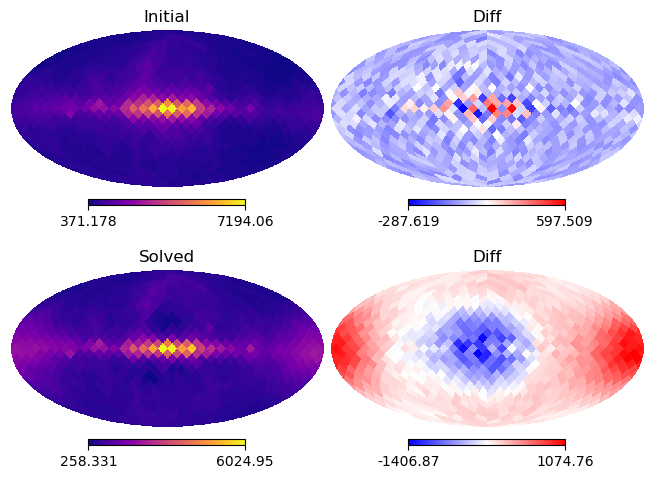

In [7]:
CH = 10
sky_ini = prms_ini['sky_coeffs'] @ sky.basis.A.T
sky_opt = prms_opt['sky_coeffs'] @ sky.basis.A.T
beam_ini = prms_ini['beam_coeffs'] @ beam.basis.A.T
beam_opt = prms_opt['beam_coeffs'] @ beam.basis.A.T
beam_recon = beam.coeffs @ beam.basis.A.T
scale_degens = [ScaleDegeneracy({'sky': 1.0, 'beam': -1.0}, group_axes=(-1,))]
map_ref = {'sky': gsm_maps_recon, 'beam': beam_recon}
maps_ini = RecoverySolution({'sky': sky_ini, 'beam': beam_ini}, scale_degens).remove_degen(map_ref, inplace=False).params
maps_opt = RecoverySolution({'sky': sky_opt, 'beam': beam_opt}, scale_degens).remove_degen(map_ref, inplace=False).params
sky_ini, beam_ini = maps_ini['sky'], maps_ini['beam']
sky_opt, beam_opt = maps_opt['sky'], maps_opt['beam']
healpy.mollview(                        sky_ini[:, CH], sub=(2, 2, 1), cmap='plasma', title='Initial')
healpy.mollview(sky_ini[:, CH] - gsm_maps_recon[:, CH], sub=(2, 2, 2), cmap='bwr'   , title='Diff')
healpy.mollview(                        sky_opt[:, CH], sub=(2, 2, 3), cmap='plasma', title='Solved')
healpy.mollview(sky_opt[:, CH] - gsm_maps_recon[:, CH], sub=(2, 2, 4), cmap='bwr'   , title='Diff')

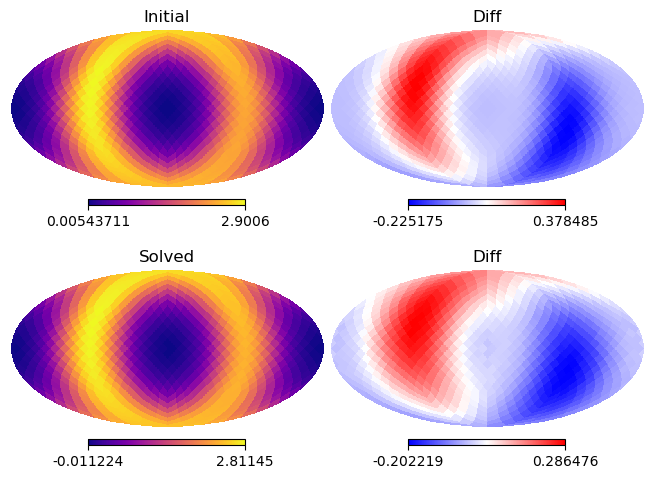

In [8]:
CH = 10
healpy.mollview(                      beam_ini[0, :, CH], sub=(2, 2, 1), cmap='plasma', title='Initial')
healpy.mollview(beam_ini[0,:, CH] - beam_recon[0, :, CH], sub=(2, 2, 2), cmap='bwr'   , title='Diff')
healpy.mollview(                      beam_opt[0, :, CH], sub=(2, 2, 3), cmap='plasma', title='Solved')
healpy.mollview(beam_opt[0,:, CH] - beam_recon[0, :, CH], sub=(2, 2, 4), cmap='bwr'   , title='Diff')

In [9]:
import pandas as pd
df = pd.DataFrame(result["telemetry"])
# Telemetry columns vary by solver (adaptive solvers add per-block step
# diagnostics); select whichever are present.
cols = [c for c in [
    "loss", "step_type", "delta_chi2_per_sec",
    "joint_step", "sky_step", "beam_step",
    "joint_loss", "sky_loss", "beam_loss",
    "sky_update_rms", "beam_update_rms",
    "beam_roughness",
] if c in df.columns]
df[cols]

,loss,step_type,delta_chi2_per_sec,beam_roughness
0,261.889606,fast-cg,6791.884841,0.783209
1,27.910603,fast-cg,5.115254,0.783290
2,11.848431,fast-cg,0.363592,0.783121
3,7.440800,fast-cg,0.097578,0.783120
4,5.601073,fast-cg+aa,0.040235,0.783080
5,4.592049,fast-cg,0.022616,0.783089
6,3.867846,fast-cg+aa,0.016240,0.783035
7,3.407952,fast-cg,0.010280,0.783058
8,3.152933,fast-cg,0.005657,0.783032
9,2.915799,fast-cg+aa,0.005292,0.783031
